# Task C: Comparison of Optimization Algorithms

## Aim

To train the same Artificial Neural Network using different optimization
algorithms such as SGD, Momentum, RMSProp, and Adam, and compare their
training loss, validation loss, convergence speed, training accuracy, and
validation accuracy.

**Name:** Janani  
**Roll No:** 24BAD039

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to the range 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


In [3]:
def create_model(optimizer):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [4]:
EPOCHS = 20
BATCH_SIZE = 128
VALIDATION_SPLIT = 0.2

In [5]:
# 1. Stochastic Gradient Descent
sgd_optimizer = SGD(learning_rate=0.01)

# 2. SGD with Momentum
momentum_optimizer = SGD(
    learning_rate=0.01,
    momentum=0.9
)

# 3. RMSProp
rmsprop_optimizer = RMSprop(
    learning_rate=0.001
)

# 4. Adam
adam_optimizer = Adam(
    learning_rate=0.001
)

In [6]:
sgd_model = create_model(sgd_optimizer)

momentum_model = create_model(momentum_optimizer)

rmsprop_model = create_model(rmsprop_optimizer)

adam_model = create_model(adam_optimizer)

c:\Users\JANANI.K\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
print("Training using SGD...")

sgd_history = sgd_model.fit(
    x_train,
    y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Training using SGD...
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6603 - loss: 1.3185 - val_accuracy: 0.8421 - val_loss: 0.6634
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8602 - loss: 0.5522 - val_accuracy: 0.8887 - val_loss: 0.4368
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8860 - loss: 0.4225 - val_accuracy: 0.9013 - val_loss: 0.3675
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8970 - loss: 0.3693 - val_accuracy: 0.9090 - val_loss: 0.3320
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9045 - loss: 0.3384 - val_accuracy: 0.9138 - val_loss: 0.3088
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9100 - loss: 0.3167 - val_accuracy: 0.9183 - val_loss: 0.2908
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9148 - loss: 0.2997 - val_accuracy: 0.9221 - val_loss: 0.2777
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9184 - loss: 0

In [11]:
print("Training using Momentum...")

momentum_history = momentum_model.fit(
    x_train,
    y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Training using Momentum...
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8436 - loss: 0.5502 - val_accuracy: 0.9199 - val_loss: 0.2755
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9295 - loss: 0.2431 - val_accuracy: 0.9443 - val_loss: 0.1979
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9465 - loss: 0.1858 - val_accuracy: 0.9526 - val_loss: 0.1675
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9568 - loss: 0.1498 - val_accuracy: 0.9565 - val_loss: 0.1445
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9649 - loss: 0.1243 - val_accuracy: 0.9604 - val_loss: 0.1326
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9697 - loss: 0.1054 - val_accuracy: 0.9647 - val_loss: 0.1205
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9741 - loss: 0.0918 - val_accuracy: 0.9657 - val_loss: 0.1134
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9772 - loss

In [8]:
print("Training using RMSProp...")

rmsprop_history = rmsprop_model.fit(
    x_train,
    y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Training using RMSProp...
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9016 - loss: 0.3509 - val_accuracy: 0.9477 - val_loss: 0.1765
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9557 - loss: 0.1516 - val_accuracy: 0.9624 - val_loss: 0.1272
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9682 - loss: 0.1053 - val_accuracy: 0.9679 - val_loss: 0.1081
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9762 - loss: 0.0807 - val_accuracy: 0.9720 - val_loss: 0.0966
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9808 - loss: 0.0628 - val_accuracy: 0.9743 - val_loss: 0.0896
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9847 - loss: 0.0514 - val_accuracy: 0.9751 - val_loss: 0.0942
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9874 - loss: 0.0417 - val_accuracy: 0.9742 - val_loss: 0.0912
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9898 - los

In [9]:
print("Training using Adam...")

adam_history = adam_model.fit(
    x_train,
    y_train,
    validation_split=VALIDATION_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Training using Adam...
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8962 - loss: 0.3736 - val_accuracy: 0.9430 - val_loss: 0.1970
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9534 - loss: 0.1568 - val_accuracy: 0.9571 - val_loss: 0.1505
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9671 - loss: 0.1114 - val_accuracy: 0.9671 - val_loss: 0.1123
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9749 - loss: 0.0839 - val_accuracy: 0.9695 - val_loss: 0.1058
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9809 - loss: 0.0651 - val_accuracy: 0.9703 - val_loss: 0.0954
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9838 - loss: 0.0538 - val_accuracy: 0.9729 - val_loss: 0.0922
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9874 - loss: 0.0427 - val_accuracy: 0.9760 - val_loss: 0.0826
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9894 - los

In [10]:
sgd_test_loss, sgd_test_accuracy = sgd_model.evaluate(
    x_test, y_test, verbose=0
)

momentum_test_loss, momentum_test_accuracy = momentum_model.evaluate(
    x_test, y_test, verbose=0
)

rmsprop_test_loss, rmsprop_test_accuracy = rmsprop_model.evaluate(
    x_test, y_test, verbose=0
)

adam_test_loss, adam_test_accuracy = adam_model.evaluate(
    x_test, y_test, verbose=0
)

print("SGD Test Accuracy:", sgd_test_accuracy)
print("Momentum Test Accuracy:", momentum_test_accuracy)
print("RMSProp Test Accuracy:", rmsprop_test_accuracy)
print("Adam Test Accuracy:", adam_test_accuracy)

SGD Test Accuracy: 0.9459999799728394
Momentum Test Accuracy: 0.10580000281333923
RMSProp Test Accuracy: 0.9750999808311462
Adam Test Accuracy: 0.9768999814987183


In [12]:
def get_final_accuracy(history):
    final_train_accuracy = history.history["accuracy"][-1]
    final_val_accuracy = history.history["val_accuracy"][-1]

    return final_train_accuracy, final_val_accuracy


sgd_train_acc, sgd_val_acc = get_final_accuracy(sgd_history)

momentum_train_acc, momentum_val_acc = get_final_accuracy(
    momentum_history
)

rmsprop_train_acc, rmsprop_val_acc = get_final_accuracy(
    rmsprop_history
)

adam_train_acc, adam_val_acc = get_final_accuracy(
    adam_history
)

In [13]:
def get_final_loss(history):
    final_train_loss = history.history["loss"][-1]
    final_val_loss = history.history["val_loss"][-1]

    return final_train_loss, final_val_loss


sgd_train_loss, sgd_val_loss = get_final_loss(sgd_history)

momentum_train_loss, momentum_val_loss = get_final_loss(
    momentum_history
)

rmsprop_train_loss, rmsprop_val_loss = get_final_loss(
    rmsprop_history
)

adam_train_loss, adam_val_loss = get_final_loss(
    adam_history
)

In [14]:
def get_convergence_epoch(history):
    val_loss = history.history["val_loss"]
    return np.argmin(val_loss) + 1


sgd_convergence = get_convergence_epoch(sgd_history)

momentum_convergence = get_convergence_epoch(
    momentum_history
)

rmsprop_convergence = get_convergence_epoch(
    rmsprop_history
)

adam_convergence = get_convergence_epoch(
    adam_history
)

print("SGD convergence epoch:", sgd_convergence)
print("Momentum convergence epoch:", momentum_convergence)
print("RMSProp convergence epoch:", rmsprop_convergence)
print("Adam convergence epoch:", adam_convergence)

SGD convergence epoch: 20
Momentum convergence epoch: 15
RMSProp convergence epoch: 5
Adam convergence epoch: 7


In [15]:
results = pd.DataFrame({
    "Optimizer": [
        "SGD",
        "Momentum",
        "RMSProp",
        "Adam"
    ],
    "Final Training Loss": [
        sgd_train_loss,
        momentum_train_loss,
        rmsprop_train_loss,
        adam_train_loss
    ],
    "Final Validation Loss": [
        sgd_val_loss,
        momentum_val_loss,
        rmsprop_val_loss,
        adam_val_loss
    ],
    "Final Training Accuracy": [
        sgd_train_acc,
        momentum_train_acc,
        rmsprop_train_acc,
        adam_train_acc
    ],
    "Final Validation Accuracy": [
        sgd_val_acc,
        momentum_val_acc,
        rmsprop_val_acc,
        adam_val_acc
    ],
    "Convergence Epoch": [
        sgd_convergence,
        momentum_convergence,
        rmsprop_convergence,
        adam_convergence
    ]
})

results

,Optimizer,Final Training Loss,Final Validation Loss,Final Training Accuracy,Final Validation Accuracy,Convergence Epoch
0,SGD,0.188374,0.187478,0.946750,0.947667,20
1,Momentum,0.021796,0.088265,0.994958,0.975167,15
2,RMSProp,0.003868,0.136987,0.999104,0.974667,5
3,Adam,0.007591,0.114577,0.997854,0.975250,7


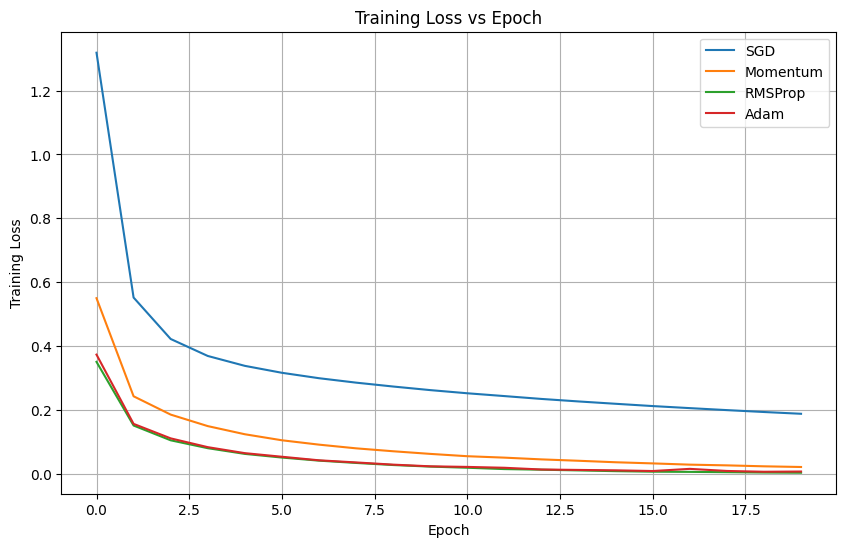

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    sgd_history.history["loss"],
    label="SGD"
)

plt.plot(
    momentum_history.history["loss"],
    label="Momentum"
)

plt.plot(
    rmsprop_history.history["loss"],
    label="RMSProp"
)

plt.plot(
    adam_history.history["loss"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.legend()
plt.grid(True)

plt.show()

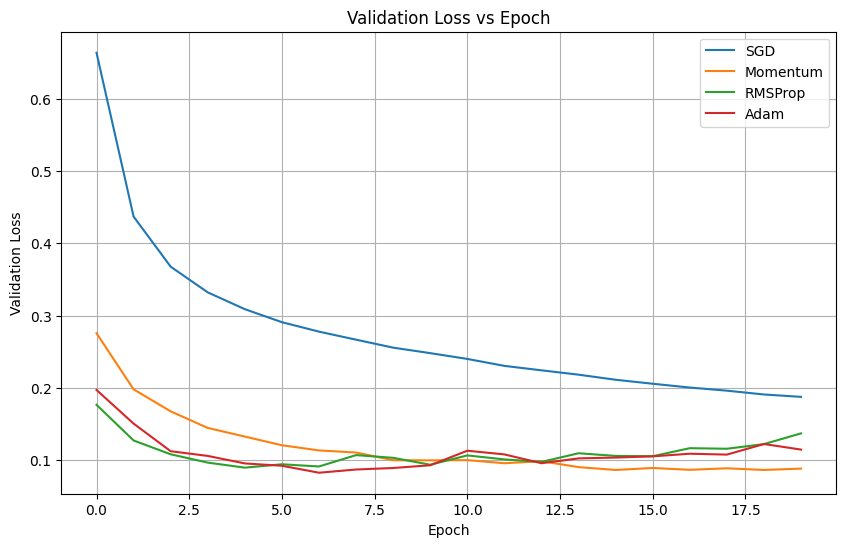

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    sgd_history.history["val_loss"],
    label="SGD"
)

plt.plot(
    momentum_history.history["val_loss"],
    label="Momentum"
)

plt.plot(
    rmsprop_history.history["val_loss"],
    label="RMSProp"
)

plt.plot(
    adam_history.history["val_loss"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")
plt.legend()
plt.grid(True)

plt.show()

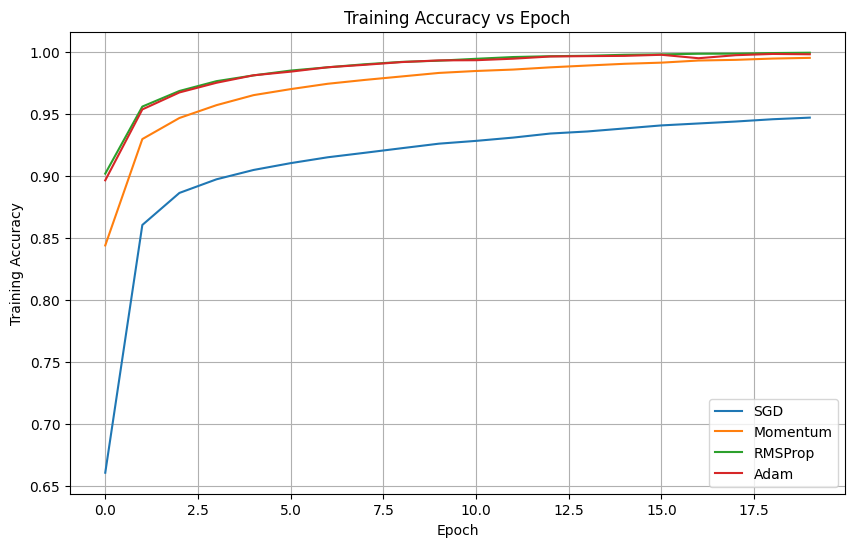

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    sgd_history.history["accuracy"],
    label="SGD"
)

plt.plot(
    momentum_history.history["accuracy"],
    label="Momentum"
)

plt.plot(
    rmsprop_history.history["accuracy"],
    label="RMSProp"
)

plt.plot(
    adam_history.history["accuracy"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.legend()
plt.grid(True)

plt.show()

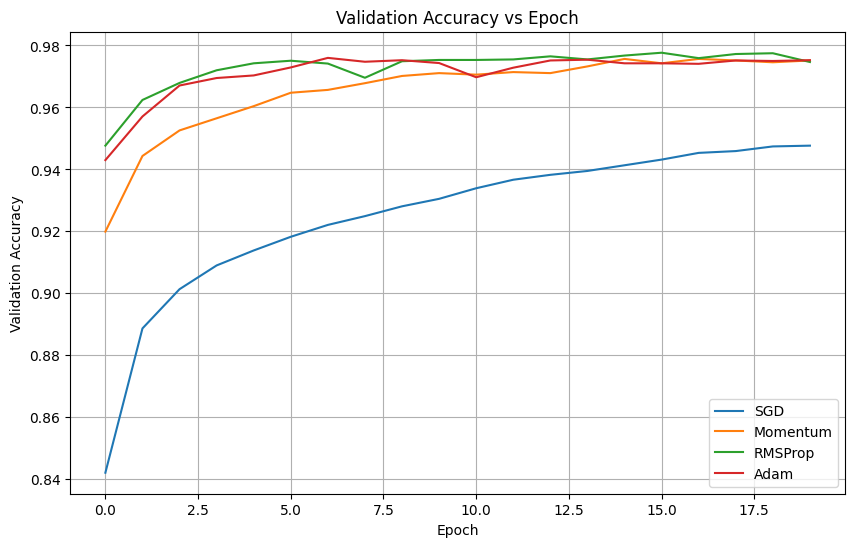

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    sgd_history.history["val_accuracy"],
    label="SGD"
)

plt.plot(
    momentum_history.history["val_accuracy"],
    label="Momentum"
)

plt.plot(
    rmsprop_history.history["val_accuracy"],
    label="RMSProp"
)

plt.plot(
    adam_history.history["val_accuracy"],
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.legend()
plt.grid(True)

plt.show()

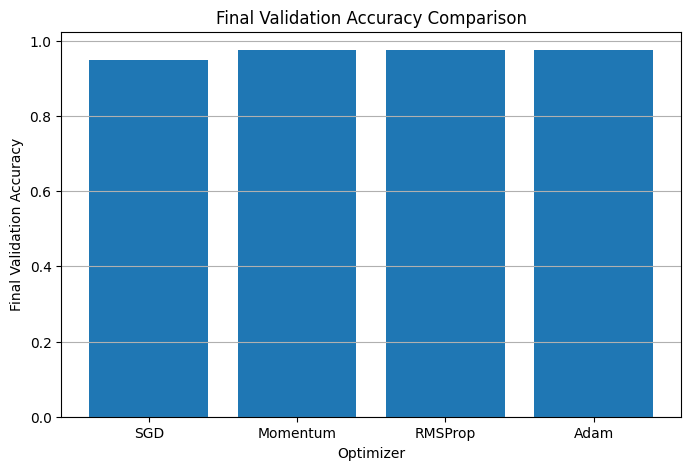

In [20]:
optimizers = ["SGD", "Momentum", "RMSProp", "Adam"]

validation_accuracies = [
    sgd_val_acc,
    momentum_val_acc,
    rmsprop_val_acc,
    adam_val_acc
]

plt.figure(figsize=(8, 5))

plt.bar(optimizers, validation_accuracies)

plt.xlabel("Optimizer")
plt.ylabel("Final Validation Accuracy")
plt.title("Final Validation Accuracy Comparison")

plt.grid(axis="y")

plt.show()

## Analysis

The same ANN architecture was trained using SGD, Momentum, RMSProp, and Adam.
The dataset, activation function, batch size, number of epochs, and validation
split were kept constant to ensure a fair comparison.

SGD generally performs weight updates without using an adaptive learning rate,
so its convergence may be slower. Momentum improves SGD by using information
from previous updates, which can accelerate convergence and reduce oscillations.

RMSProp adapts the learning rate according to the recent magnitude of
gradients, which can improve training stability. Adam combines momentum-like
behavior with adaptive learning rates and often achieves fast convergence.

The optimizer with the highest validation accuracy and lowest validation loss
provides better generalization for this experiment. The optimizer reaching
its minimum validation loss in fewer epochs can be considered to have faster
convergence.